In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn tensorflow evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.3/568.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.2 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%

Missing values: 0

Data types:
float64    30
int64       1
Name: count, dtype: int64


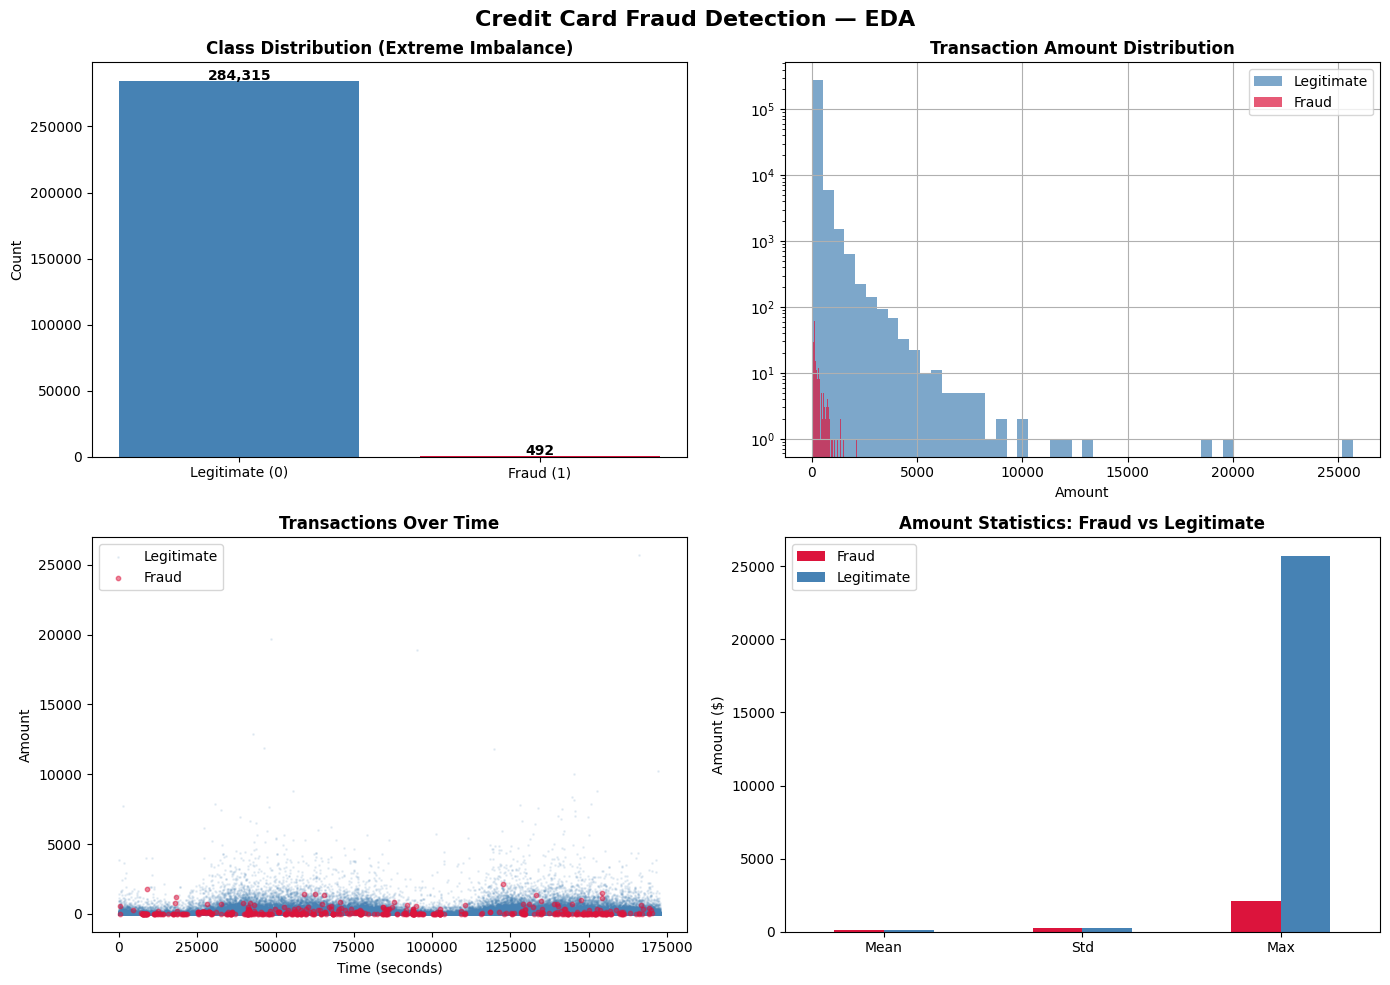

✅ EDA charts saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution
axes[0,0].bar(['Legitimate (0)', 'Fraud (1)'],
               df['Class'].value_counts().values,
               color=['steelblue', 'crimson'])
axes[0,0].set_title('Class Distribution (Extreme Imbalance)', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df['Class'].value_counts().values):
    axes[0,0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 2. Transaction amount by class
df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0,1],
                                   color='steelblue', alpha=0.7, label='Legitimate')
df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[0,1],
                                   color='crimson', alpha=0.7, label='Fraud')
axes[0,1].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0,1].set_xlabel('Amount')
axes[0,1].legend()
axes[0,1].set_yscale('log')

# 3. Fraud over time
axes[1,0].scatter(df[df['Class']==0]['Time'],
                   df[df['Class']==0]['Amount'],
                   alpha=0.1, s=1, color='steelblue', label='Legitimate')
axes[1,0].scatter(df[df['Class']==1]['Time'],
                   df[df['Class']==1]['Amount'],
                   alpha=0.5, s=10, color='crimson', label='Fraud')
axes[1,0].set_title('Transactions Over Time', fontweight='bold')
axes[1,0].set_xlabel('Time (seconds)')
axes[1,0].set_ylabel('Amount')
axes[1,0].legend()

# 4. Amount statistics comparison
fraud_stats = df[df['Class']==1]['Amount'].describe()
legit_stats = df[df['Class']==0]['Amount'].describe()
stats_df = pd.DataFrame({'Fraud': fraud_stats, 'Legitimate': legit_stats})
stats_df.loc[['mean','std','max']].plot(kind='bar', ax=axes[1,1],
                                         color=['crimson','steelblue'])
axes[1,1].set_title('Amount Statistics: Fraud vs Legitimate', fontweight='bold')
axes[1,1].set_xticklabels(['Mean','Std','Max'], rotation=0)
axes[1,1].set_ylabel('Amount ($)')

plt.suptitle('Credit Card Fraud Detection — EDA', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved!")

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
print(f"Class distribution: {Counter(y_train_smote)}")
print("✅ Preprocessing complete!")
# 1. Scale Amount and Time (V1-V28 are already PCA scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# 2. Add engineered features
df['Amount_log'] = np.log1p(df['Amount'])  # log transform skewed amount
df['Hour'] = (df['Time'] // 3600) % 24     # extract hour of day

# 3. Drop original unscaled columns
features = [c for c in df.columns if c not in ['Time', 'Amount', 'Class']]
X = df[features]
y = df['Class']

print(f"Features used: {len(features)}")
print(f"Feature list: {features}")

# 4. Train/test split BEFORE SMOTE (important — never SMOTE test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"\nTrain fraud count before SMOTE: {y_train.sum()}")

# 5. Apply SMOTE only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train size: {X_train_smote.shape}")
print(f"Class distribution: {Counter(y_train_smote)}")
print("✅ Preprocessing complete!")

Class distribution: Counter({0: 227451, 1: 227451})
✅ Preprocessing complete!
Features used: 32
Feature list: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled', 'Amount_log', 'Hour']

Train size: (227845, 32)
Test size: (56962, 32)

Train fraud count before SMOTE: 394

After SMOTE:
Train size: (454902, 32)
Class distribution: Counter({0: 227451, 1: 227451})
✅ Preprocessing complete!


In [8]:
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              RocCurveDisplay, PrecisionRecallDisplay)
import time

print("🚀 Training XGBoost...")
start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,       # 1 because SMOTE already balanced
    eval_metric='aucpr',      # area under precision-recall (better for imbalanced)
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=50
)

elapsed = time.time() - start
print(f"\n✅ Training complete in {elapsed:.1f}s")

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("\n" + "="*50)
print("📊 XGBOOST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score:              {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision Score:    {average_precision_score(y_test, y_pred_proba):.4f}")
print("="*50)

🚀 Training XGBoost...
[0]	validation_0-aucpr:0.52309
[50]	validation_0-aucpr:0.71631
[100]	validation_0-aucpr:0.82177
[150]	validation_0-aucpr:0.83802
[200]	validation_0-aucpr:0.85174
[250]	validation_0-aucpr:0.85512
[299]	validation_0-aucpr:0.86158

✅ Training complete in 39.1s

📊 XGBOOST RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.59      0.86      0.70        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score:              0.9842
Average Precision Score:    0.8618


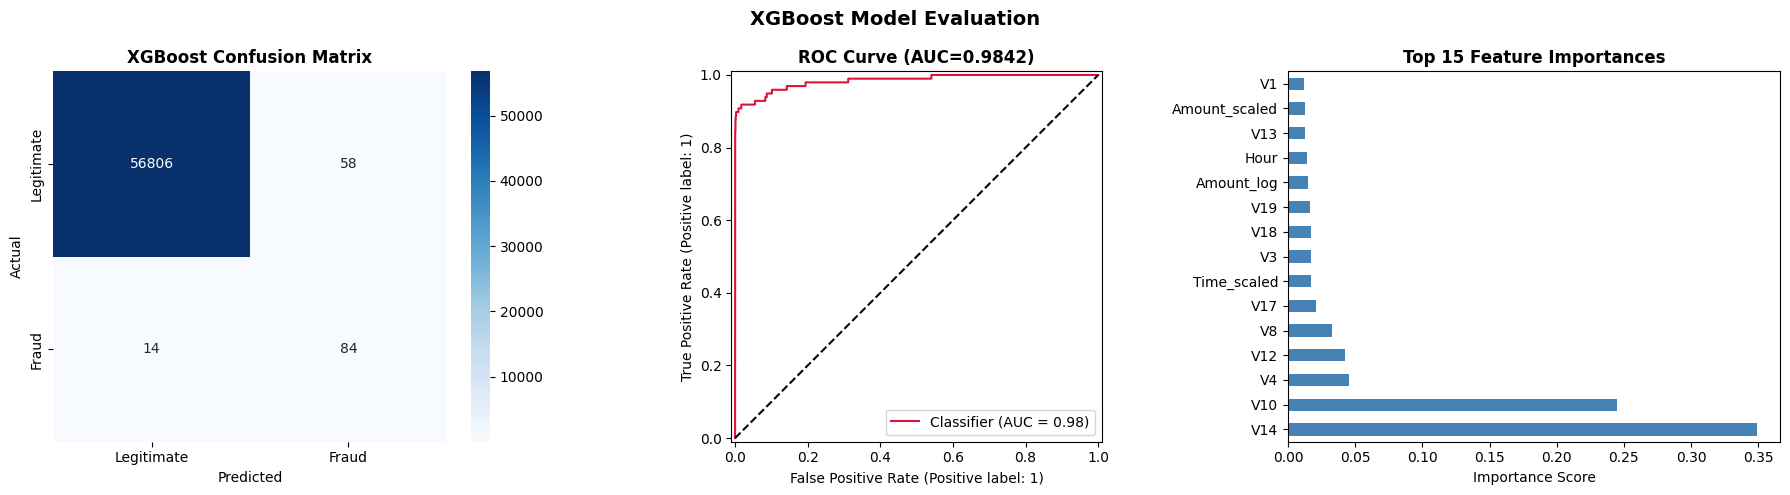

✅ XGBoost evaluation saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('XGBoost Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1],
                                   color='crimson')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve (AUC=0.9842)', fontweight='bold')

# 3. Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_,
                      index=X_train_smote.columns)
feat_imp.nlargest(15).plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 15 Feature Importances', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('XGBoost Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ XGBoost evaluation saved!")

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Train autoencoder ONLY on legitimate transactions
X_train_legit = X_train_smote[y_train_smote == 0]
print(f"Training autoencoder on {len(X_train_legit)} legitimate transactions...")

input_dim = X_train_legit.shape[1]  # 32 features

# Build Autoencoder architecture
inputs = Input(shape=(input_dim,))

# Encoder — compress down
x = Dense(64, activation='relu')(inputs)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
encoded = Dense(16, activation='relu')(x)  # bottleneck

# Decoder — reconstruct back up
x = Dense(32, activation='relu')(encoded)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Train
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

history = autoencoder.fit(
    X_train_legit, X_train_legit,  # input = output (reconstruction)
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print("✅ Autoencoder training complete!")

Training autoencoder on 227451 legitimate transactions...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,456 (36.94 KB)

 Trainable params: 9,456 (36.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.5848 - val_loss: 1.1599 - learning_rate: 0.0010
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.8906 - val_loss: 1.1828 - learning_rate: 0.0010
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7594 - val_loss: 1.1901 - learning_rate: 0.0010
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7067 - val_loss: 1.1626 - learning_rate: 0.0010
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6651 - val_loss: 1.1475 - learning_rate: 0.0010
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6373 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5965 - val_loss: 1.0935 - learning_rate: 0.0010
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5616 - val_loss: 0.9807 - learning_rate: 0.0010
Epoch 9/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5439 - val_loss: 0.9984 - learning_rate: 0.0010
E

Autoencoder threshold: 1.6544

📊 AUTOENCODER RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     56864
       Fraud       0.03      0.86      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.51     56962
weighted avg       1.00      0.95      0.97     56962

ROC-AUC: 0.9331

📊 ENSEMBLE RESULTS (XGBoost 70% + Autoencoder 30%)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.72      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9705
Average Precision: 0.8278


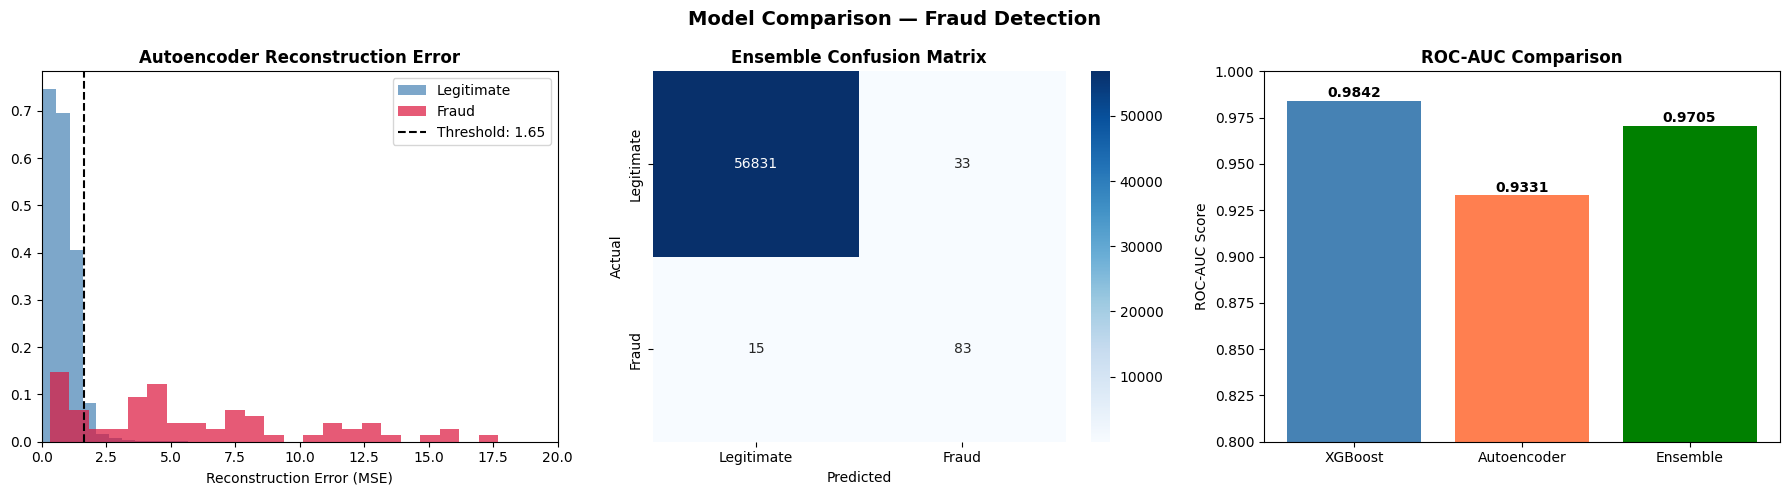

✅ Ensemble evaluation complete!


In [11]:
import numpy as np

# Get reconstruction errors on test set
X_test_reconstructed = autoencoder.predict(X_test, verbose=0)
reconstruction_errors = np.mean(np.power(X_test.values - X_test_reconstructed, 2), axis=1)

# Find optimal threshold using 95th percentile of legitimate errors
legit_errors = reconstruction_errors[y_test == 0]
threshold = np.percentile(legit_errors, 95)
print(f"Autoencoder threshold: {threshold:.4f}")

# Autoencoder predictions
ae_pred = (reconstruction_errors > threshold).astype(int)
ae_scores = reconstruction_errors  # raw anomaly score

# Evaluate autoencoder alone
print("\n" + "="*50)
print("📊 AUTOENCODER RESULTS")
print("="*50)
print(classification_report(y_test, ae_pred,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, ae_scores):.4f}")

# ============================================
# ENSEMBLE — combine XGBoost + Autoencoder
# ============================================
from sklearn.preprocessing import MinMaxScaler

# Normalize both scores to [0, 1]
xgb_scores = y_pred_proba
ae_scores_norm = MinMaxScaler().fit_transform(ae_scores.reshape(-1,1)).flatten()

# Weighted ensemble (XGBoost is stronger so give it more weight)
ensemble_scores = 0.7 * xgb_scores + 0.3 * ae_scores_norm
ensemble_pred = (ensemble_scores > 0.5).astype(int)

print("\n" + "="*50)
print("📊 ENSEMBLE RESULTS (XGBoost 70% + Autoencoder 30%)")
print("="*50)
print(classification_report(y_test, ensemble_pred,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, ensemble_scores):.4f}")
print(f"Average Precision: {average_precision_score(y_test, ensemble_scores):.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reconstruction error distribution
axes[0].hist(reconstruction_errors[y_test==0], bins=100,
             alpha=0.7, color='steelblue', label='Legitimate', density=True)
axes[0].hist(reconstruction_errors[y_test==1], bins=100,
             alpha=0.7, color='crimson', label='Fraud', density=True)
axes[0].axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.2f}')
axes[0].set_title('Autoencoder Reconstruction Error', fontweight='bold')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].legend()
axes[0].set_xlim(0, 20)

# Confusion matrices comparison
for ax, (preds, title) in zip(axes[1:], [
    (ensemble_pred, 'Ensemble Confusion Matrix'),
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

# Model comparison bar chart
models = ['XGBoost', 'Autoencoder', 'Ensemble']
roc_scores = [
    roc_auc_score(y_test, xgb_scores),
    roc_auc_score(y_test, ae_scores),
    roc_auc_score(y_test, ensemble_scores)
]
bars = axes[2].bar(models, roc_scores, color=['steelblue', 'coral', 'green'])
axes[2].set_ylim(0.8, 1.0)
axes[2].set_title('ROC-AUC Comparison', fontweight='bold')
axes[2].set_ylabel('ROC-AUC Score')
for bar, score in zip(bars, roc_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison — Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ensemble_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Ensemble evaluation complete!")

In [12]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save XGBoost
joblib.dump(xgb_model, 'models/xgboost_fraud.pkl')

# Save Autoencoder
autoencoder.save('models/autoencoder_fraud.keras')

# Save scaler and feature info
joblib.dump(scaler, 'models/scaler.pkl')

feature_config = {
    'features': list(X_train_smote.columns),
    'ae_threshold': float(threshold),
    'xgb_weight': 0.7,
    'ae_weight': 0.3,
    'ensemble_threshold': 0.5
}
joblib.dump(feature_config, 'models/feature_config.pkl')

print("✅ All models saved!")
print("\nFiles saved:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f}: {size:.1f} KB")

✅ All models saved!

Files saved:
  feature_config.pkl: 0.3 KB
  xgboost_fraud.pkl: 1013.3 KB
  autoencoder_fraud.keras: 160.6 KB
  scaler.pkl: 0.9 KB


In [13]:
from google.colab import files
import shutil

# Zip models folder
shutil.make_archive('models', 'zip', 'models')
files.download('models.zip')

# Download charts
for f in ['eda_overview.png', 'xgboost_results.png', 'ensemble_results.png']:
    files.download(f)

# Download notebook
print("✅ Also go to File → Download → .ipynb to save the notebook!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Also go to File → Download → .ipynb to save the notebook!
